<a href="https://colab.research.google.com/github/johen10/Streamlit-Radars/blob/main/Field_PL_Wyscout_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing the required modules
import glob
import pandas as pd

# specifying the path to csv files
path = r"/content/drive/MyDrive/Colab Notebooks/Wyscout/data"

# csv files in the path
file_list = glob.glob(path + "/*.xlsx")

# list of excel files we want to merge.
# pd.read_excel(file_path) reads the
# excel data into pandas dataframe.
excl_list = []

for file in file_list:
    excl_list.append(pd.read_excel(file))

# concatenate all DataFrames in the list
# into a single DataFrame, returns new
# DataFrame.
excl_merged = pd.concat(excl_list, ignore_index=True)

# exports the dataframe into excel file
# with specified name.
excl_merged.to_excel('Sporting DMS.xlsx', index=False)

ValueError: No objects to concatenate

In [ ]:
%pip install soccerplots
%pip install mplsoccer
%pip install round_percentages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import numpy as np
from matplotlib.colors import to_rgba
from soccerplots.radar_chart import Radar
from scipy import stats
import math
from mplsoccer import PyPizza, add_image, FontManager
import matplotlib.pyplot as mpl
mpl.rcParams['figure.dpi'] = 300

import scipy.stats as stats
from tabulate import tabulate
import urllib
import os
import round_percentages


In [ ]:
from google.colab import files
import io
uploaded = files.upload()

Saving 2ª Liga.xlsx to 2ª Liga.xlsx


In [ ]:
df = pd.read_excel("2ª Liga.xlsx")

In [ ]:
df = df.fillna(0)

In [ ]:
df.head(10)

,Player,Team,Position,Age,Market value,Contract expires,Matches played,Minutes played,Goals,xG,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
0,F. Valverde,Real Madrid,"RCMF, RW",27,120000000,2029-06-30,37,3172,2,3.49,...,0.0,0.65,0.0,0.0,0.14,0.14,40.00,0.00,0,0.0
1,D. Rice,Arsenal,"DMF, LCMF",26,120000000,2028-06-30,38,3601,7,3.96,...,0.0,0.72,0.0,0.0,0.25,0.07,33.33,1.17,0,0.0
2,Bruno Guimarães,Newcastle United,"DMF, LCMF",27,85000000,0,37,3689,7,5.36,...,0.0,0.46,0.0,0.0,0.29,0.00,0.00,0.05,0,0.0
3,A. Mac Allister,Liverpool,"DMF, RCMF, LCMF",26,75000000,2028-06-30,33,2897,5,3.03,...,0.0,1.03,0.0,0.0,0.19,0.06,0.00,0.34,1,100.0
4,F. de Jong,Barcelona,"LDMF, RDMF",28,70000000,2029-06-30,20,1844,2,0.72,...,0.0,0.78,0.0,0.0,0.05,0.00,0.00,0.05,0,0.0
5,Douglas Luiz,Nottingham Forest,"LCMF, LDMF",27,70000000,2029-06-30,35,3401,9,8.35,...,0.0,1.01,0.0,0.0,0.77,0.13,20.00,2.65,4,100.0
6,K. Mainoo,Manchester United,"RDMF, LDMF, LCMF",20,55000000,2027-06-30,24,2072,3,1.00,...,0.0,0.52,0.0,0.0,0.00,0.00,0.00,0.00,0,0.0
7,João Palhinha,Tottenham Hotspur,"RDMF, LDMF, LCMF",30,55000000,2028-06-30,33,3022,4,3.98,...,0.0,0.68,0.0,0.0,0.06,0.00,0.00,0.00,0,0.0
8,Matheus Nunes,Manchester City,"RDMF, LDMF, LW",27,50000000,2028-06-30,19,959,0,1.09,...,0.0,0.28,0.0,0.0,0.19,0.00,0.00,0.38,0,0.0
9,Mikel Merino,Arsenal,LCMF,29,50000000,2028-06-30,32,2741,5,4.08,...,0.0,0.49,0.0,0.0,0.00,0.00,0.00,0.00,0,0.0


In [ ]:
#COM TOP 5
df = df[df["Team"].str.contains('Athletic Bilbao') == False]
df = df[df["Team"].str.contains('Bayern') == False]
df = df[df["Team"].str.contains('Dortmund') == False]
df = df[df["Team"].str.contains('Bayer 04') == False]
df = df[df["Team"].str.contains('RB Leipzig') == False]
df = df[df["Team"].str.contains('Vfl Wolfsburg') == False]
df = df[df["Team"].str.contains('Real Madrid') == False]
df = df[df["Team"].str.contains('Barcelona') == False]
df = df[df["Team"].str.contains('Sevilla') == False]
df = df[df["Team"].str.contains('Atletico') == False]
df = df[df["Team"].str.contains('PSG') == False]
df = df[df["Team"].str.contains('Marseille') == False]
df = df[df["Team"].str.contains('Lyon') == False]
df = df[df["Team"].str.contains('Inter') == False]
df = df[df["Team"].str.contains('Napoli') == False]
df = df[df["Team"].str.contains('Lazio') == False]
df = df[df["Team"].str.contains('Roma') == False]
df = df[df["Team"].str.contains('Napoli') == False]
df = df[df["Team"].str.contains('Juventus') == False]
df = df[df["Team"].str.contains('Milan') == False]
df = df[df["Team"].str.contains('Porto') == False]
df = df[df["Team"].str.contains('Benfica') == False]
df = df[df["Team"].str.contains('Sporting CP') == False]
df = df[df["Team"].str.contains('Ajax') == False]
df = df[df["Team"].str.contains('PSV') == False]
df = df[df["Team"].str.contains('Galatasaray') == False]
df = df[df["Team"].str.contains('Monaco') == False]
df = df[df["Team"].str.contains('Nottingham') == False]
df = df[df["Team"].str.contains('RB Salzburg') == False]
df = df[df["Team"].str.contains('Nice') == False]
df = df[df["Team"].str.contains('Lille') == False]
df = df[df["Team"].str.contains('Tottenham') == False]
df = df[df["Team"].str.contains('Atlético Madrid') == False]
df = df[df["Team"].str.contains('Chelsea') == False]
df = df[df["Team"].str.contains('Manchester City') == False]
df = df[df["Team"].str.contains('Manchester United') == False]
df = df[df["Team"].str.contains('Arsenal') == False]
df = df[df["Team"].str.contains('Newcastle') == False]
df = df[df["Team"].str.contains('Liverpool') == False]
df = df[df["Team"].str.contains('Bayer Leverkusen') == False]
df = df[df["Team"].str.contains('Aston Villa') == False]
df = df[df["Team"].str.contains('Atalanta') == False]
df = df[df["Team"].str.contains('Liverpool') == False]
df = df[df["Team"].str.contains('Porto') == False]
df = df[df["Team"].str.contains('Benfica') == False]
df = df[df["Team"].str.contains('Sporting CP') == False]
df = df[df["Team"].str.contains('Ajax') == False]
df = df[df["Team"].str.contains('PSV') == False]
df = df[df["Team"].str.contains('Galatasaray') == False]
df = df[df["Team"].str.contains('RB Salzburg') == False]
df = df[df["Team"].str.contains('Feyenoord') == False]
df = df[df["Team"].str.contains('Girona') == False]
df = df[df["Team"].str.contains('Real Sociedad') == False]
df = df[df["Team"].str.contains('Rennes') == False]
df = df[df["Team"].str.contains('Fulham') == False]
df = df[df["Team"].str.contains('Everton') == False]
df = df[df["Team"].str.contains('Eintracht Frankfurt') == False]
df = df[df["Team"].str.contains('Stuttgart') == False]
df = df[df["Team"].str.contains('Wisła Kraków') == False]
df = df[df["Team"].str.contains('Crystal Palace') == False]
df = df[df["Team"].str.contains('Como') == False]
df = df[df["Team"].str.contains('Heracles') == False]
df = df[df["Team"].str.contains('Willem II') == False]

In [ ]:
df = df[(df['Minutes played']) > 1000]
df = df[(df['Age']) < 24]
df = df[(df['Market value']) < 40000000]

In [ ]:
#Defesa Central

df = df[(df['Position'].str.contains('CB'))]



df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Crosses per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Touches in box per 90', 'Accelerations per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Deep completed crosses per 90', 'Accurate progressive passes, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'SuccessfulDefActions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'Dribbles', 'Offensive Duels', 'xA', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Passes', 'Progressive Runs', 'SuccessfulDefActions', 'Defensive Duels', 'Aerial Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['SuccessfulDefActions'] = df['SuccessfulDefActions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Passes'] = stats.zscore(df['Progressive Passes'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['Aerial Duels'] = stats.zscore(df['Aerial Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['SuccessfulDefActions'] = stats.zscore(df['SuccessfulDefActions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Passes'] = df['Progressive Passes'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['SuccessfulDefActions'] = df['SuccessfulDefActions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['Aerial Duels'] = df['Aerial Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Defesa'] = (df['SuccessfulDefActions']*0.3 + df['Defensive Duels']*0.3 + df['PAdj Sliding Tackles']*0.2 + df['PAdj Interceptions']*0.2)*0.3
df['Posse'] = (df['Offensive Duels']*0.2 + df['Dribbles']*0.20  + df['Progressive Passes']*0.3 + df['Progressive Runs']*0.3)*0.7



df['Ranking']=  df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()

df['Defesa'] = df['Defesa'].rank(pct=True)
df.Defesa = df.Defesa.round(2)
df['Defesa'] = df['Defesa']*100

df['Posse'] = df['Posse'].rank(pct=True)
df.Posse = df.Posse.round(2)
df['Posse'] = df['Posse']*100


df =df.sort_values(by=['Ranking'], ascending=False)
df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)
df['Ranking'] = df['Ranking']*100


In [ ]:
#Defesa Lateral Esquerdo

df = df[(df['Position'].str.contains('LB'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box' }, inplace=True)


df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Deep Completed Crosses'] = stats.zscore(df['Deep Completed Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Aerial Duels'] = stats.zscore(df['Aerial Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Deep Completed Crosses'] = df['Deep Completed Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Aerial Duels'] = df['Aerial Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = df['Succesful Attack Actions']*0.2 + df['Dribbles']*0.3 + df['Offensive Duels']*0.3 + df['xA']*0.2
df['Atque'] = df['Ataque']*0.45
df['Defesa'] = (df['Successful_Def_Actions']*0.25 + df['Defensive Duels']*0.35 + df['PAdj Sliding Tackles']*0.2 + df['PAdj Interceptions']*0.2)*0.3
df['Posse'] = (df['Smart Passes']*0.05 + df['Progressive Passes']*0.1 + df['Progressive Runs']*0.25 + df['Crosses']*0.3 + df['Deep Completed Crosses']*0.3)*0.25



df['Ranking']= df['Ataque1'] + df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque1']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Defesa Lateral Direito

df = df[(df['Position'].str.contains('RB|RB5'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Accelerations per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'Dribbles', 'Offensive Duels', 'xA', 'Touches in Box', 'Crosses', 'Deep Completed Crosses', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Passes', 'Progressive Runs', 'Successful_Def_Actions', 'Defensive Duels', 'Aerial Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)
df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Deep Completed Crosses'] = stats.zscore(df['Deep Completed Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Aerial Duels'] = stats.zscore(df['Aerial Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Deep Completed Crosses'] = df['Deep Completed Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Aerial Duels'] = df['Aerial Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.2 + df['Dribbles']*0.3 + df['Offensive Duels']*0.3 + df['xA']*0.2)
df['Atque'] = df['Ataque']*0.45
df['Defesa'] = (df['Successful_Def_Actions']*0.25 + df['Defensive Duels']*0.35 + df['PAdj Sliding Tackles']*0.2 + df['PAdj Interceptions']*0.2)*0.3
df['Posse'] = (df['Smart Passes']*0.05 + df['Progressive Passes']*0.1 + df['Progressive Runs']*0.25 + df['Crosses']*0.3 + df['Deep Completed Crosses']*0.3)*0.25



df['Ranking']= df['Ataque'] + df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Ala Lateral Direito

df = df[(df['Position'].str.contains('RWB|RB5'))]


df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Accelerations per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'Dribbles', 'Offensive Duels', 'xA', 'Touches in Box', 'Crosses', 'Deep Completed Crosses', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Passes', 'Progressive Runs', 'Successful_Def_Actions', 'Defensive Duels', 'Aerial Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Deep Completed Crosses'] = stats.zscore(df['Deep Completed Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Aerial Duels'] = stats.zscore(df['Aerial Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Deep Completed Crosses'] = df['Deep Completed Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Aerial Duels'] = df['Aerial Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.2 + df['Dribbles']*0.2 + df['Offensive Duels']*0.3 + df['xA']*0.2 + df['Touches in Box']*0.1)
df['Atque'] = df['Ataque']*0.6
df['Defesa'] = (df['Successful_Def_Actions']*0.3 + df['Defensive Duels']*0.3 + df['PAdj Sliding Tackles']*0.2 + df['PAdj Interceptions']*0.2)*0.2
df['Posse'] = (df['Passes to Final 3rd']*0.1  + df['Progressive Runs']*0.4 + df['Crosses']*0.3 + df['Deep Completed Crosses']*0.2)*0.2



df['Ranking']= df['Ataque'] + df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Ala Lateral Esquerdo

df = df[(df['Position'].str.contains('LWB|LB5'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Accelerations per 90', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'Dribbles', 'Offensive Duels', 'xA', 'Touches in Box', 'Crosses', 'Deep Completed Crosses', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Passes', 'Progressive Runs', 'Successful_Def_Actions', 'Defensive Duels', 'Aerial Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Deep Completed Crosses'] = stats.zscore(df['Deep Completed Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Aerial Duels'] = stats.zscore(df['Aerial Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Deep Completed Crosses'] = df['Deep Completed Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Aerial Duels'] = df['Aerial Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.2 + df['Dribbles']*0.2 + df['Offensive Duels']*0.3 + df['xA']*0.2 + df['Touches in Box']*0.1)
df['Atque'] = df['Ataque']*0.6
df['Defesa'] = (df['Successful_Def_Actions']*0.3 + df['Defensive Duels']*0.3 + df['PAdj Sliding Tackles']*0.2 + df['PAdj Interceptions']*0.2)*0.2
df['Posse'] = (df['Passes to Final 3rd']*0.1  + df['Progressive Runs']*0.4 + df['Crosses']*0.3 + df['Deep Completed Crosses']*0.2)*0.2



df['Ranking']= df['Ataque'] + df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Médio Defensivo
df = df[(df['Position'].str.contains('DMF'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Accelerations per 90', 'Deep completed crosses per 90', 'Crosses per 90', 'Goal conversion, %', 'Offensive duels per 90' ], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Aerial duels per 90': 'Aerial Duels', 'Passes to penalty area per 90': 'Passes to Penalty Area', 'Deep completions per 90': 'Deep Completions', 'Received passes per 90': 'Received Passes'}, inplace=True)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['xA'] = stats.zscore(df['xA'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Received Passes'] = stats.zscore(df['Received Passes'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Passes to Penalty Area'] = stats.zscore(df['Passes to Penalty Area'])
df['Progressive Passes'] = stats.zscore(df['Progressive Passes'])
df['Deep Completions'] = stats.zscore(df['Deep Completions'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])

df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Received Passes'] = df['Received Passes'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Passes to Penalty Area'] = df['Passes to Penalty Area'].rank(pct=True)
df['Progressive Passes'] = df['Progressive Passes'].rank(pct=True)
df['Deep Completions'] = df['Deep Completions'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Defesa'] = (df['Successful_Def_Actions']*0.3 + df['Defensive Duels']*0.4 + df['PAdj Sliding Tackles']*0.15 + df['PAdj Interceptions']*0.15)*0.40
df['Posse'] = (df['Progressive Runs']*0.2 + df['Received Passes']*0.2 + df['Smart Passes']*0.20 + df['Progressive Passes']*0.4)*0.6

df['Ranking']=  df['Posse'] + df['Defesa']

df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()


df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)

df['Ranking'] = df['Ranking']*100

In [ ]:
#Médio Centro

df = df[(df['Position'].str.contains('CM|DMF'))]


df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Accelerations per 90', 'Deep completed crosses per 90', 'Crosses per 90', 'Goal conversion, %', 'Offensive duels per 90' ], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Aerial duels per 90': 'Aerial Duels', 'Passes to penalty area per 90': 'Passes to Penalty Area', 'Deep completions per 90': 'Deep Completions', 'Received passes per 90': 'Received Passes'}, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'xA', 'Shots', 'Dribbles', 'Touches in Box', 'Progressive Runs', 'Received Passes', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Passes to Penalty Area', 'Progressive Passes', 'Deep Completions', 'Successful_Def_Actions', 'Defensive Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)

df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['xA'] = stats.zscore(df['xA'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Received Passes'] = stats.zscore(df['Received Passes'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Passes to Penalty Area'] = stats.zscore(df['Passes to Penalty Area'])
df['Progressive Passes'] = stats.zscore(df['Progressive Passes'])
df['Deep Completions'] = stats.zscore(df['Deep Completions'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Received Passes'] = df['Received Passes'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Passes to Penalty Area'] = df['Passes to Penalty Area'].rank(pct=True)
df['Progressive Passes'] = df['Progressive Passes'].rank(pct=True)
df['Deep Completions'] = df['Deep Completions'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.5 + df['Touches in Box']*0.2 + df['Shots']*0.1)
df['Atque'] = df['Ataque']*0.3
df['Defesa'] = (df['Successful_Def_Actions']*0.35 + df['Defensive Duels']*0.35 + df['PAdj Sliding Tackles']*0.15 + df['PAdj Interceptions']*0.15)*0.2
df['Posse'] = (df['Progressive Runs']*0.2 + df['Received Passes']*0.2 + df['Smart Passes']*0.15 + df['Passes to Final 3rd']*0.05  + df['Progressive Passes']*0.2 + df['Deep Completions']*0.2)*0.5


df['Ranking']= df['Ataque'] + df['Posse'] + df['Defesa']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()
df['Defesa']=df['Defesa'] - df['Defesa'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Médio Ofensivo

df = df[(df['Position'].str.contains('CM|AMF'))]


df=df.drop(['Position', 'Age', 'Contract expires', 'Offensive duels per 90', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Accelerations per 90', 'Deep completed crosses per 90', 'Crosses per 90', 'Goal conversion, %'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value', 'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Aerial duels per 90': 'Aerial Duels', 'Passes to penalty area per 90': 'Passes to Penalty Area', 'Deep completions per 90': 'Deep Completions', 'Received passes per 90': 'Received Passes'}, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'xA', 'Shots', 'Dribbles', 'Touches in Box', 'Progressive Runs', 'Received Passes', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Passes to Penalty Area', 'Progressive Passes', 'Deep Completions', 'Successful_Def_Actions', 'Defensive Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)
df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['xA'] = stats.zscore(df['xA'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Received Passes'] = stats.zscore(df['Received Passes'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Passes to Penalty Area'] = stats.zscore(df['Passes to Penalty Area'])
df['Progressive Passes'] = stats.zscore(df['Progressive Passes'])
df['Deep Completions'] = stats.zscore(df['Deep Completions'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Received Passes'] = df['Received Passes'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Passes to Penalty Area'] = df['Passes to Penalty Area'].rank(pct=True)
df['Progressive Passes'] = df['Progressive Passes'].rank(pct=True)
df['Deep Completions'] = df['Deep Completions'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.15 + df['xG']*0.1 + df['Dribbles']*0.1 + df['xA']*0.3 + df['Touches in Box']*0.15 + df['Shots']*0.2)
df['Atque'] = df['Ataque']*0.4
df['Posse'] = (df['Progressive Runs']*0.15 + df['Key Passes']*0.25 + df['Passes to Final 3rd']*0.2 + df['Passes to Penalty Area']*0.25 + df['Deep Completions']*0.15)*0.6


df['Ranking']= df['Ataque'] + df['Posse']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()



df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
#Extremo Esquerdo

df = df[(df['Position'].str.contains('LW|LWF|LAMF'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Progressive passes per 90', 'Accelerations per 90'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value' ,'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Accelerations per 90': 'Accelerations' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'xA', 'Shots', 'Dribbles', 'Offensive Duels', 'Touches in Box', 'Crosses', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Runs', 'Successful_Def_Actions', 'Defensive Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.15 + df['xG']*0.1 + df['Shots']*0.05 + df['Dribbles']*0.2 + df['Offensive Duels']*0.3 + df['xA']*0.1 + df['Touches in Box']*0.1)*0.7
df['Posse'] = (df['Crosses']*0.15 + df['Smart Passes']*0.25 + df['Key Passes']*0.25 + df['Passes to Final 3rd']*0.1 + df['Progressive Runs']*0.25)*0.3


df['Ranking']= df['Ataque'] + df['Posse']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()

df['Ataque'] = df['Ataque'].rank(pct=True)
df.Ataque = df.Ataque.round(2)
df['Ataque'] = df['Ataque']*100

df['Posse'] = df['Posse'].rank(pct=True)
df.Posse = df.Posse.round(2)
df['Posse'] = df['Posse']*100

df =df.sort_values(by=['Ranking'], ascending=False)
df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)
df['Ranking'] = df['Ranking']*100


In [ ]:
#Extremo Direito

df = df[(df['Position'].str.contains('RW|RWF|RAMF'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Goal conversion, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Passes to penalty area per 90', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Progressive passes per 90', 'Accelerations per 90'], axis=1).reset_index()
df.rename(columns={'Market value': 'Market Value' ,'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Crosses per 90': 'Crosses', 'Deep completed crosses per 90': 'Deep Completed Crosses', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Accelerations per 90': 'Accelerations' }, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'xA', 'Shots', 'Dribbles', 'Offensive Duels', 'Touches in Box', 'Crosses', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Progressive Runs', 'Successful_Def_Actions', 'Defensive Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Crosses'] = stats.zscore(df['Crosses'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Crosses'] = df['Crosses'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.15 + df['xG']*0.1 + df['Shots']*0.05 + df['Dribbles']*0.2 + df['Offensive Duels']*0.3 + df['xA']*0.1 + df['Touches in Box']*0.1)
df['Atque'] = df['Ataque']*0.7
df['Posse'] = (df['Crosses']*0.15 + df['Smart Passes']*0.25 + df['Key Passes']*0.25 + df['Passes to Final 3rd']*0.1 + df['Progressive Runs']*0.25)*0.3


df['Ranking']= df['Ataque'] + df['Posse']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()



df['Ataque'] = df['Ataque'].rank(pct=True)
df.Ranking = df.Ranking.round(2)
df['Ataque'] = df['Ataque']*100

df['Posse'] = df['Posse'].rank(pct=True)
df.Ranking = df.Ranking.round(2)
df['Posse'] = df['Posse']*100

df =df.sort_values(by=['Ranking'], ascending=False)
df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)
df['Ranking'] = df['Ranking']*100


In [ ]:
#Avançado

df = df[(df['Position'].str.contains('CF'))]

df=df.drop(['Position', 'Age', 'Contract expires', 'Matches played', 'Minutes played', 'Defensive duels won, %', 'Aerial duels won, %', 'Shots blocked per 90', 'Fouls per 90', 'Non-penalty goals per 90', 'Shots on target, %', 'Assists per 90', 'Accurate crosses, %', 'Crosses from left flank per 90', 'Accurate crosses from left flank, %', 'Crosses from right flank per 90', 'Accurate crosses from right flank, %', 'Crosses to goalie box per 90', 'Successful dribbles, %', 'Offensive duels won, %', 'Received passes per 90', 'Received long passes per 90', 'Fouls suffered per 90', 'Shot assists per 90', 'Second assists per 90', 'Accurate smart passes, %', 'Third assists per 90', 'Accurate smart passes, %', 'Accurate passes to final third, %', 'Accurate passes to penalty area, %', 'Accurate through passes, %', 'Deep completions per 90', 'Accurate progressive passes, %', 'Aerial duels per 90', 'Deep completed crosses per 90', 'Accelerations per 90', 'Deep completed crosses per 90', 'Crosses per 90' ], axis=1).reset_index()
df.rename(columns={'Successful defensive actions per 90': 'Successful_Def_Actions', 'Defensive duels per 90': 'Defensive Duels', 'Aerial duels per 90': 'Aerial Duels', 'PAdj Sliding tackles': 'PAdj Sliding Tackles', 'Successful attacking actions per 90': 'Succesful Attack Actions', 'xG per 90': 'xG', 'Dribbles per 90': 'Dribbles', 'Offensive duels per 90': 'Offensive Duels', 'Progressive runs per 90': 'Progressive Runs', 'xA per 90': 'xA', 'Smart passes per 90': 'Smart Passes', 'Key passes per 90':'Key Passes', 'Passes to final third per 90': 'Passes to Final 3rd', 'Progressive passes per 90': 'Progressive Passes', 'Touches in box per 90': 'Touches in Box', 'Shots per 90': 'Shots', 'Aerial duels per 90': 'Aerial Duels', 'Passes to penalty area per 90': 'Passes to Penalty Area' , 'Goal conversion, %': 'Goal Conversion %'}, inplace=True)
column_names = ['index', 'Player', 'Team', 'Market Value', 'Succesful Attack Actions', 'xG', 'xA', 'Shots', 'Goal Conversion %', 'Dribbles', 'Offensive Duels', 'Touches in Box', 'Progressive Runs', 'Smart Passes', 'Key Passes', 'Passes to Final 3rd', 'Passes to Penalty Area', 'Progressive Passes', 'Successful_Def_Actions', 'Defensive Duels', 'PAdj Sliding Tackles', 'PAdj Interceptions']
df = df.reindex(columns=column_names)

df['Successful_Def_Actions'] = df['Successful_Def_Actions'].astype(float)


df['Succesful Attack Actions'] = stats.zscore(df['Succesful Attack Actions'])
df['xG'] = stats.zscore(df['xG'])
df['Shots'] = stats.zscore(df['Shots'])
df['Dribbles'] = stats.zscore(df['Dribbles'])
df['Goal Conversion %'] = stats.zscore(df['Goal Conversion %'])
df['Offensive Duels'] = stats.zscore(df['Offensive Duels'])
df['xA'] = stats.zscore(df['xA'])
df['Touches in Box'] = stats.zscore(df['Touches in Box'])
df['Smart Passes'] = stats.zscore(df['Smart Passes'])
df['Key Passes'] = stats.zscore(df['Key Passes'])
df['Passes to Final 3rd'] = stats.zscore(df['Passes to Final 3rd'])
df['Progressive Runs'] = stats.zscore(df['Progressive Runs'])
df['Successful_Def_Actions'] = stats.zscore(df['Successful_Def_Actions'])
df['Defensive Duels'] = stats.zscore(df['Defensive Duels'])
df['PAdj Sliding Tackles'] = stats.zscore(df['PAdj Sliding Tackles'])
df['PAdj Interceptions'] = stats.zscore(df['PAdj Interceptions'])


df['Succesful Attack Actions'] = df['Succesful Attack Actions'].rank(pct=True)
df['xG'] = df['xG'].rank(pct=True)
df['Shots'] = df['Shots'].rank(pct=True)
df['Dribbles'] = df['Dribbles'].rank(pct=True)
df['Goal Conversion %'] = df['Goal Conversion %'].rank(pct=True)
df['Offensive Duels'] = df['Offensive Duels'].rank(pct=True)
df['xA'] = df['xA'].rank(pct=True)
df['Touches in Box'] = df['Touches in Box'].rank(pct=True)
df['Smart Passes'] = df['Smart Passes'].rank(pct=True)
df['Key Passes'] = df['Key Passes'].rank(pct=True)
df['Passes to Final 3rd'] = df['Passes to Final 3rd'].rank(pct=True)
df['Progressive Runs'] = df['Progressive Runs'].rank(pct=True)
df['Successful_Def_Actions'] = df['Successful_Def_Actions'].rank(pct=True)
df['Defensive Duels'] = df['Defensive Duels'].rank(pct=True)
df['PAdj Sliding Tackles'] = df['PAdj Sliding Tackles'].rank(pct=True)
df['PAdj Interceptions'] = df['PAdj Interceptions'].rank(pct=True)



df['Ataque'] = (df['Succesful Attack Actions']*0.2 + df['xG']*0.3 + df['Shots']*0.1 + df['Dribbles']*0.05 + df['Offensive Duels']*0.05 + df['Touches in Box']*0.2 + df['Goal Conversion %']*0.2)*0.8
df['Posse'] = (df['Key Passes']*0.5 + df['Progressive Runs']*0.3)*0.2

df['Ranking']= df['Ataque'] + df['Posse']


df['Ranking']=df['Ranking'] - df['Ranking'].min()
df['Ataque']=df['Ataque'] - df['Ataque'].min()
df['Posse']=df['Posse'] - df['Posse'].min()


df['Ataque'] = df['Ataque'].rank(pct=True)
df.Ataque = df.Ataque.round(2)
df['Ataque'] = df['Ataque']*100

df['Posse'] = df['Posse'].rank(pct=True)
df.Posse = df.Posse.round(2)
df['Posse'] = df['Posse']*100

df =df.sort_values(by=['Ranking'], ascending=False)

df['Ranking'] = df['Ranking'].rank(pct=True)
df.Ranking = df.Ranking.round(2)


df['Ranking'] = df['Ranking']*100


In [ ]:
df.head(15)

,index,Player,Team,Market Value,Goals,xG,Assists,xA,Foot,Height,...,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %",Defesa,Posse,Ranking
49,447,M. Sangaré,Lens,1200000,2,0.882353,1,0.426471,left,178,...,0.0,0.00,0.00,0.0,0.04,0,0.0,0.625892,0.460000,100.0
24,356,E. Camavinga,Real Madrid,0,0,0.362745,2,0.828431,left,185,...,0.0,0.00,0.00,0.0,0.00,0,0.0,0.688967,0.393529,99.0
4,77,N. Rovella,Lazio,18000000,0,0.058824,1,0.308824,right,179,...,0.0,0.31,0.06,0.0,1.01,0,0.0,0.658333,0.384118,98.0
55,507,Y. Titraoui,Charleroi,1500000,2,0.921569,0,0.735294,right,170,...,0.0,0.00,0.00,0.0,0.04,0,0.0,0.432564,0.446471,97.0
18,282,O. Targhalline,Feyenoord,2500000,0,0.049020,0,0.078431,right,186,...,0.0,0.00,0.00,0.0,0.08,0,0.0,0.325923,0.511765,96.0
46,438,S. Scheperman,Heracles,0,1,0.558824,1,0.009804,left,188,...,0.0,0.00,0.00,0.0,0.00,0,0.0,0.704373,0.125294,95.0
16,235,T. Krauß,Bochum,4000000,1,0.343137,2,0.397059,right,182,...,0.0,0.00,0.00,0.0,0.00,0,0.0,0.483480,0.288824,94.0
94,754,E. Tıknaz,Beşiktaş,1500000,4,0.852941,2,0.338235,right,193,...,0.0,0.00,0.00,0.0,0.00,0,0.0,0.512785,0.246471,93.0
79,634,H. Hackney,Middlesbrough,0,5,0.970588,3,0.950980,right,178,...,0.0,0.04,0.04,0.0,0.11,0,0.0,0.201978,0.536471,92.0
22,343,Pablo Barrios,Atlético Madrid,0,0,0.377451,1,0.308824,right,181,...,0.0,0.00,0.00,0.0,0.05,0,0.0,0.351059,0.384706,91.0


FileNotFoundError: [Errno 2] No such file or directory: 'figures/pretty_example.png'

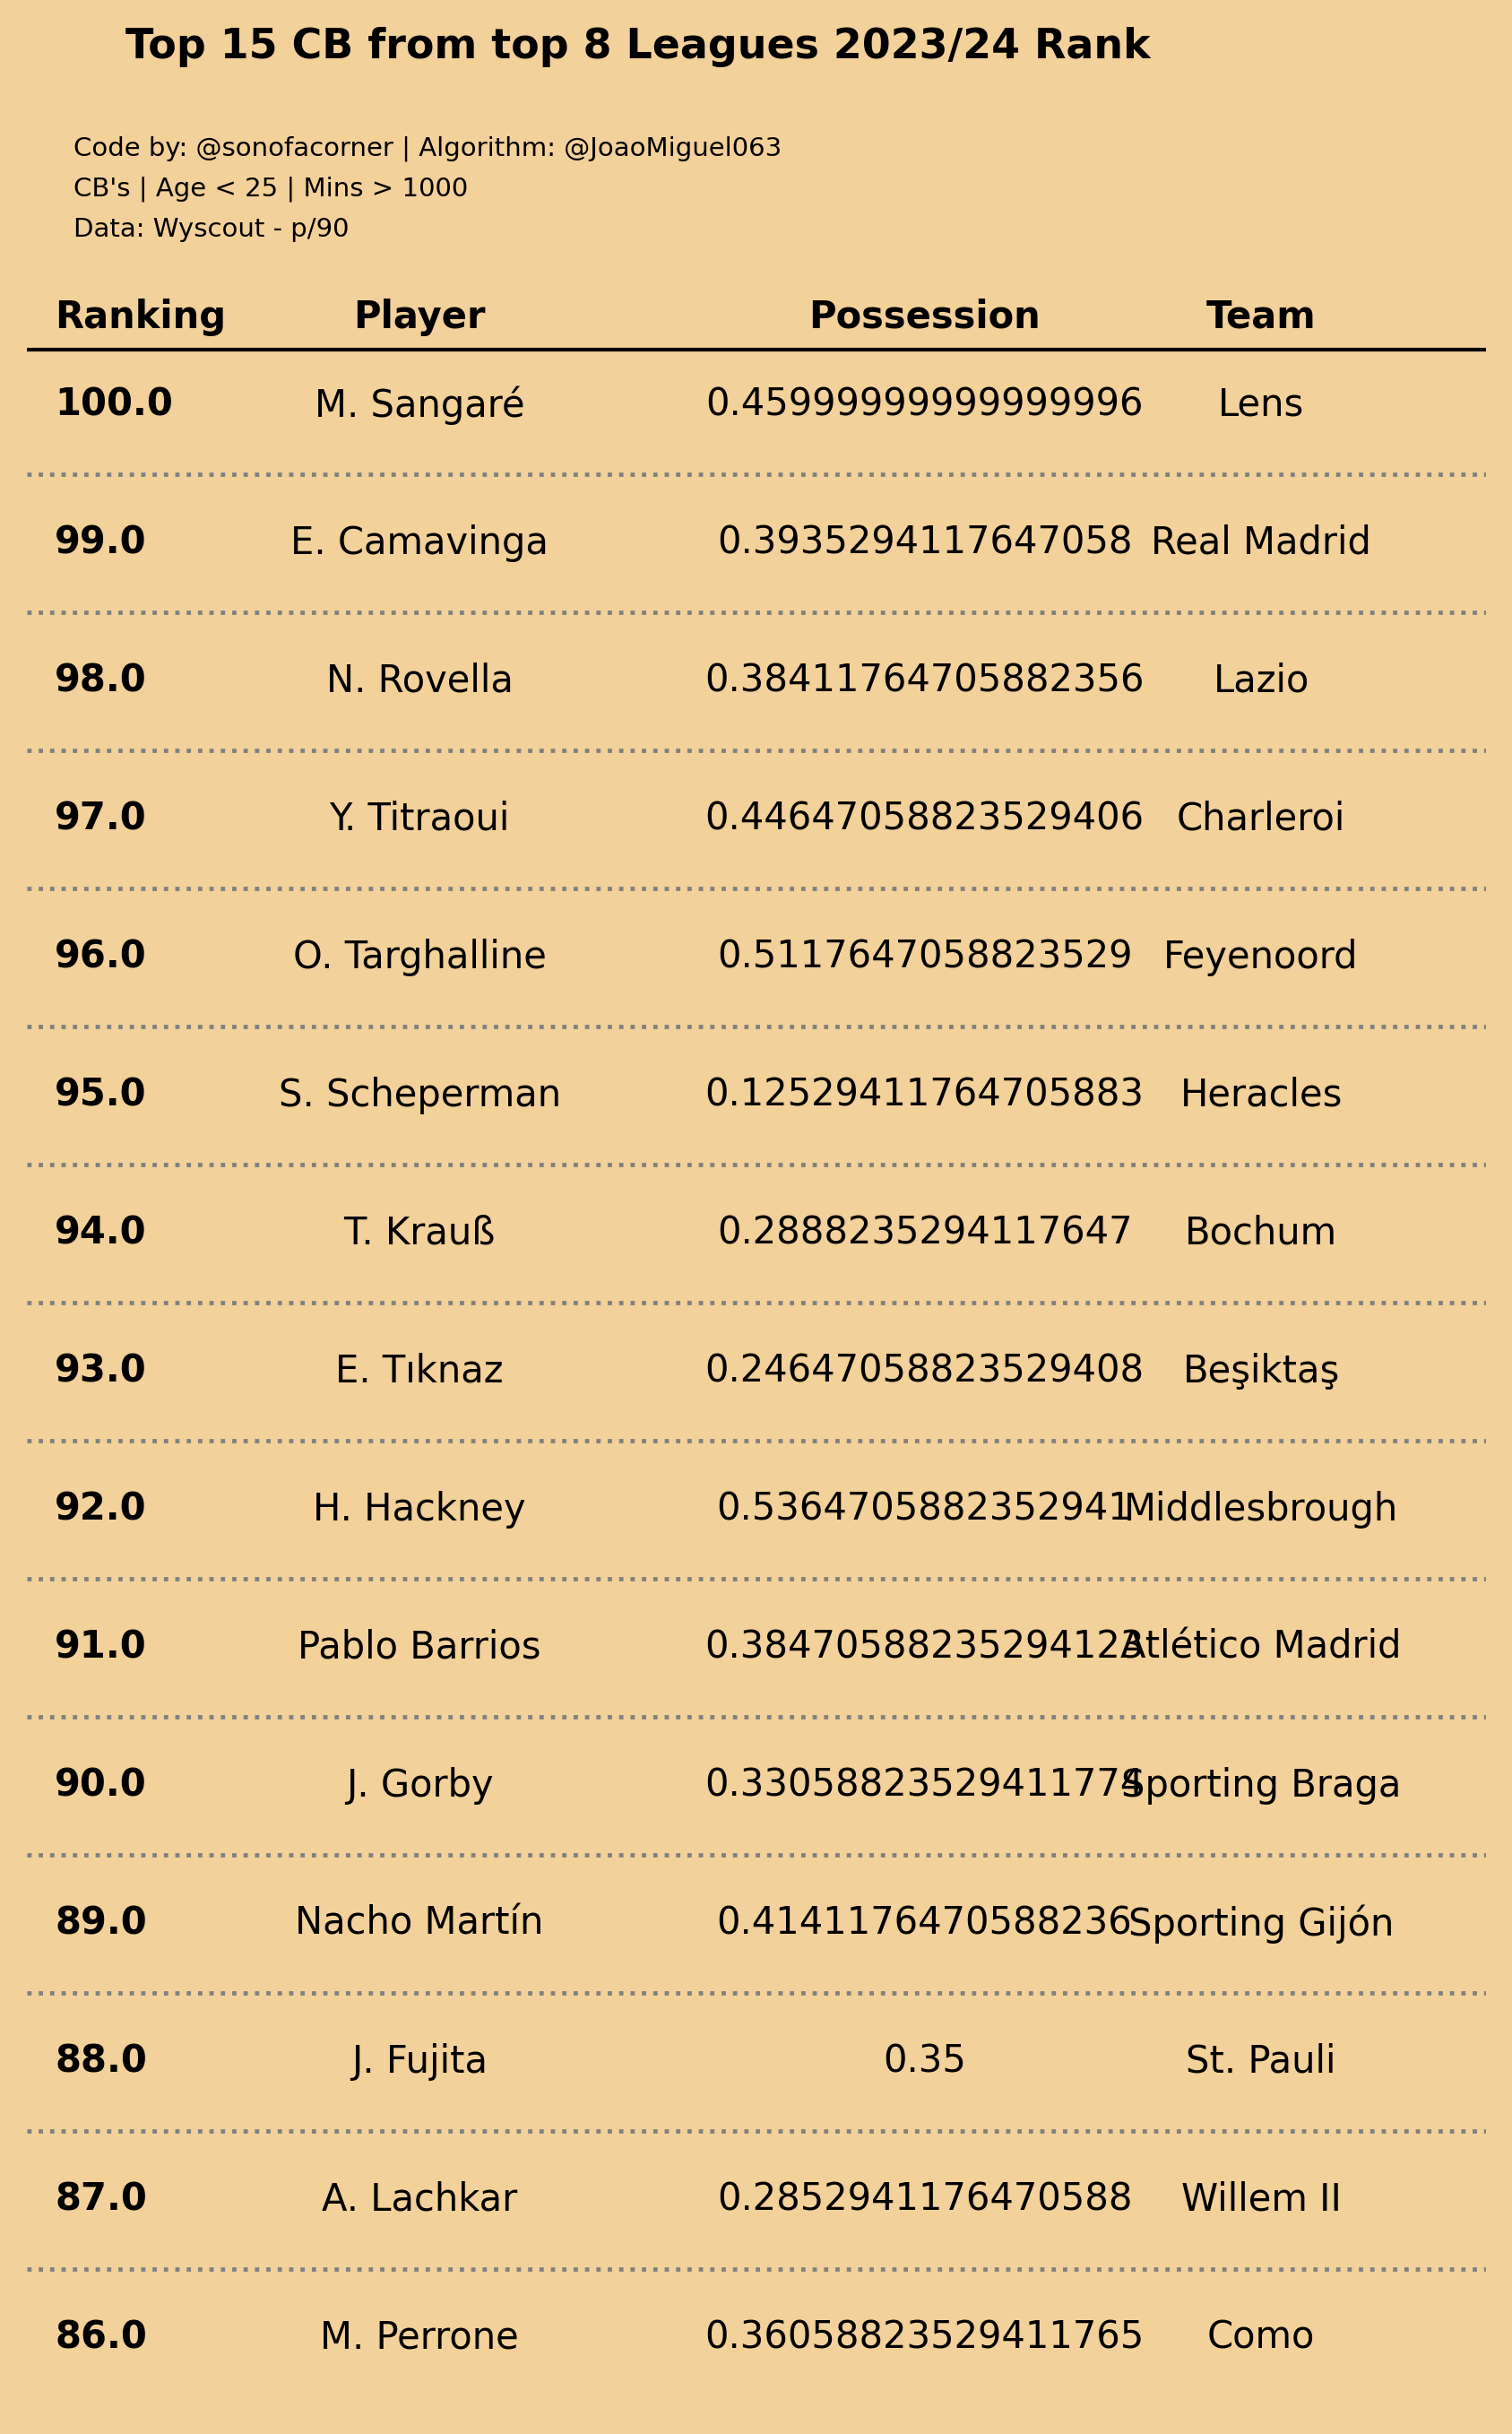

In [ ]:
fig = plt.figure(figsize=(7,10), dpi=300, facecolor='#f2d19a')
ax = plt.subplot()

nrcolumns = 12
nrows = 15

ax.set_xlim(0, nrcolumns + 1)
ax.set_ylim(0, nrows)

positions = [0.25, 3.5, 8, 11]
columns = ['Ranking','Player', 'Posse', 'Team']

# Add table's main text
for i in range(nrows):
    for j, column in enumerate(columns):
        if j == 0:
            ha = 'left'
        else:
            ha = 'center'
        if column == 'Ranking':
            text_label = f'{df[column].iloc[i]}'
            weight = 'bold'
        else:
            text_label = f'{df[column].iloc[i]}'
            weight = 'normal'
        ax.annotate(
            xy=(positions[j], i + .5),
            text=text_label,
            ha=ha,
            va='center',
            weight=weight
        )

# Add column names
column_names = ['Ranking','Player', 'Possession', 'Team']
for index, c in enumerate(column_names):
        if index == 0:
            ha = 'left'
        else:
            ha = 'center'
        ax.annotate(
            xy=(positions[index], 0),
            text=column_names[index],
            ha=ha,
            va='bottom',
            weight='bold'
        )

fig.text(x=0.17, y=.98, s=' Top 15 CB from top 8 Leagues 2023/24 Rank',
    ha='left',
    va='bottom',
    weight='bold',
    size=11
)

fig.text(x=0.15, y=.915, s='Data: Wyscout - p/90',
    ha='left',
    va='bottom',
    weight='light',
    size=7
)

fig.text(x=0.15, y=.93, s="CB's | Age < 25 | Mins > 1000",
    ha='left',
    va='bottom',
    weight='light',
    size=7
)

fig.text(x=0.15, y=.945, s='Code by: @sonofacorner | Algorithm: @JoaoMiguel063',
    ha='left',
    va='bottom',
    weight='light',
    size=7
)

# Add dividing lines
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0.1, 0.1], lw=1, color='black', marker='', zorder=4)
ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [24.75, 24.75], lw=1, color='black', marker='', zorder=4)
for x in range(1, nrows):
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [x, x], lw=1.15, color='gray', ls=':', zorder=4 , marker='')

plt.gca().invert_yaxis()
ax.set_axis_off()
plt.savefig(
    'figures/pretty_example.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)